In [6]:
%load_ext autotime
%matplotlib inline

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 1.22 ms (started: 2026-05-26 08:29:52 +03:00)


In [7]:
import time

start_time = time.perf_counter()

time: 431 μs (started: 2026-05-26 08:29:55 +03:00)


In [ ]:
import socket
from pathlib import Path

import chdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from chdb import datastore as ds
from IPython.display import display


time: 636 μs (started: 2026-05-26 08:34:41 +03:00)


In [ ]:
hostname = socket.gethostname()
in_docker = True
if hostname == "home-NMH-WDX9":
    in_docker = False

if in_docker:
    file = (Path(Path.cwd().parent) / "db/raw_data/test/cars_sales.parquet").as_posix()
else:
    file = (
        Path(Path.cwd().parent.parent.parent)
        / "datasets/raw_data/test/cars_sales.parquet"
    ).as_posix()

dsf = ds.read_parquet(file)  # type: ignore

time: 1.55 ms (started: 2026-05-26 08:37:20 +03:00)


In [32]:
with pd.option_context(
    "display.float_format",
    "{:.2f}".format,
):
    display(dsf.describe()[["price", "year", "mileage", "power"]])


,price,year,mileage,power
count,1294757.00,724644.00,771799.00,1273353.00
mean,1444357.82,2009.68,154893.40,141.56
std,1970257.41,9.37,100738.34,65.64
min,270.00,1936.00,1000.00,1.00
25%,425000.00,2003.00,82000.00,98.00
50%,870000.00,2011.00,144000.00,128.00
75%,1765000.00,2017.00,211000.00,163.00
max,150000000.00,2023.00,1000000.00,1000.00


time: 454 ms (started: 2026-05-26 09:27:25 +03:00)


In [6]:
%%time
dsf_info = dsf.info()
dsf_info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294757 entries, 0 to 1294756
Data columns (total 18 columns):
  #   Column                Non-Null Count    Dtype  
 --  --------------------  ----------------  -----  
  0   brand                 1294757 non-null  object
  1   name                  1294757 non-null  object
  2   bodyType              1294757 non-null  object
  3   color                 1257029 non-null  object
  4   fuelType              1289815 non-null  object
  5   year                  724644 non-null   float64
  6   mileage               771799 non-null   float64
  7   transmission          1289563 non-null  object
  8   power                 1273353 non-null  float64
  9   price                 1294757 non-null  int64
 10   vehicleConfiguration  724647 non-null   object
 11   engineName            720976 non-null   object
 12   engineDisplacement    717625 non-null   object
 13   date                  1294757 non-null  datetime64[ns, UTC]
 14   location         

In [ ]:
%%time
total_rows, total_null_val, types, table = mm.custom_info(dsf)
with pd.option_context(
    "display.expand_frame_repr",
    False,
    "display.max_colwidth",
    None,  # ширина столбцов — 50 символов
):
    display(table)
    print(
        f"Всего записей: {total_rows}, Null значений: {total_null_val}, Типы данных: {types}"
    )

,Column,Non-Null Count,Non-Null Count %,Null Count,Null Count %,Total Rows,Dtype
0,brand,1294757,100.000000,0,0.000000,1294757,object
1,name,1294757,100.000000,0,0.000000,1294757,object
2,bodyType,1294757,100.000000,0,0.000000,1294757,object
3,color,1257029,97.090000,37728,2.910000,1294757,object
4,fuelType,1289815,99.620000,4942,0.380000,1294757,object
5,year,724644,55.970000,570113,44.030000,1294757,float64
6,mileage,771799,59.610000,522958,40.390000,1294757,float64
7,transmission,1289563,99.600000,5194,0.400000,1294757,object
8,power,1273353,98.350000,21404,1.650000,1294757,float64
9,price,1294757,100.000000,0,0.000000,1294757,int64


Всего записей: 1294757, Null значений: 2923714, Типы данных: datetime64[ns, UTC](2), float64(3), int64(1), object(12)
CPU times: user 4.42 s, sys: 2.2 s, total: 6.62 s
Wall time: 1.36 s


In [ ]:
%%time

cl = dsf.columns.to_list()
cl.remove("link")
cl.remove("description")

dfs = []
sample_size_per_group = 10000

for group_id in range(1, 4):  # группы 1, 2, 3
    query = f"""
    WITH ranked AS (
        SELECT {",".join(cl)}, NTILE(3) OVER (ORDER BY rand()) AS tile
        FROM file('{file}', 'Parquet') # CSV
    )
    SELECT * FROM ranked
    WHERE tile = {group_id}
    ORDER BY rand()
    LIMIT {sample_size_per_group}
    """
    dfs.append(chdb.query(query, "DataFrame"))

CPU times: user 10.8 s, sys: 3.04 s, total: 13.9 s
Wall time: 3.25 s


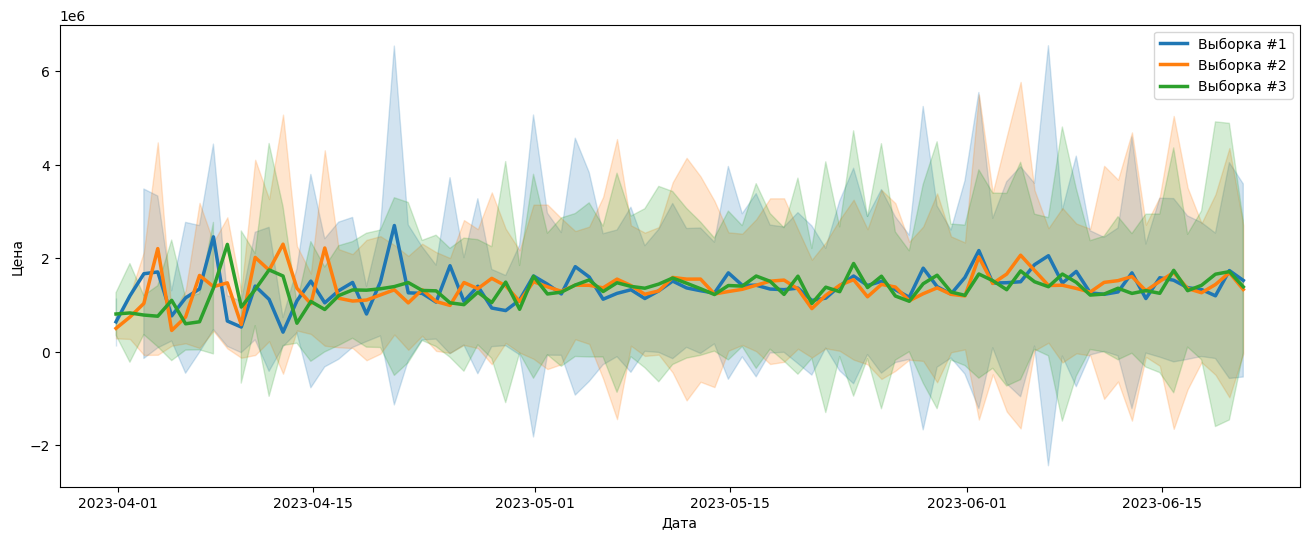

CPU times: user 720 ms, sys: 38.9 ms, total: 759 ms
Wall time: 733 ms


In [ ]:
%%time
plt.figure(figsize=(16, 6))
for idx, df_number in enumerate(dfs, 1):
    sns.lineplot(
        x="date",
        y="price",
        data=df_number,
        linewidth=2.5,
        errorbar="sd",
        label=f"Выборка #{idx}",
    )
plt.xlabel("Дата")
plt.ylabel("Цена")
plt.show()

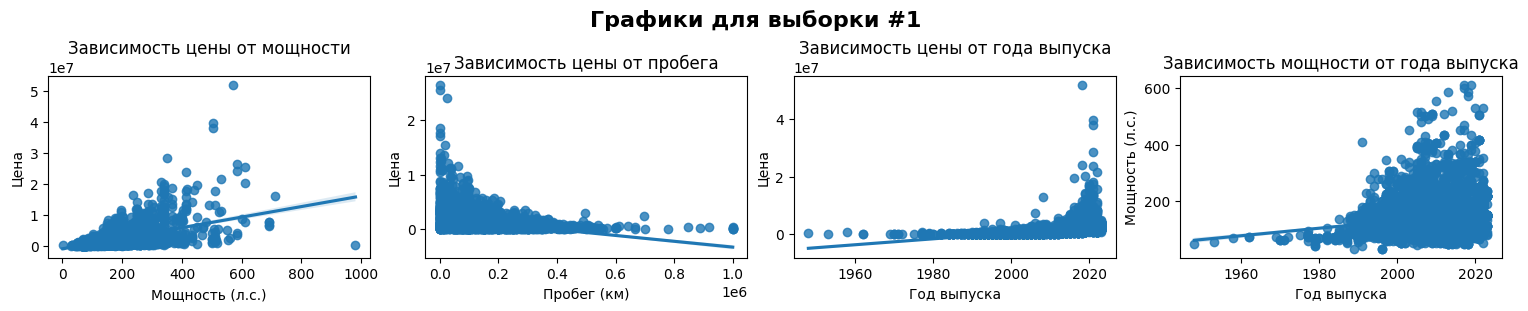

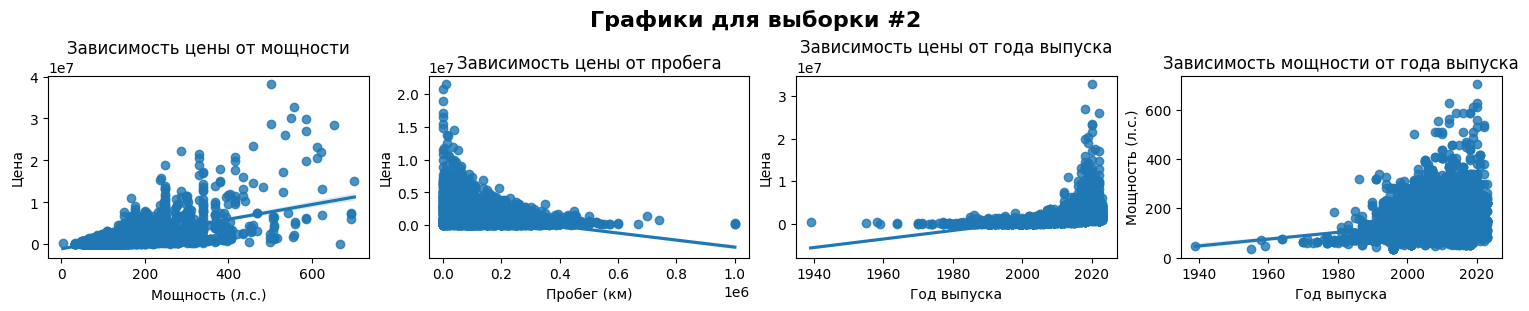

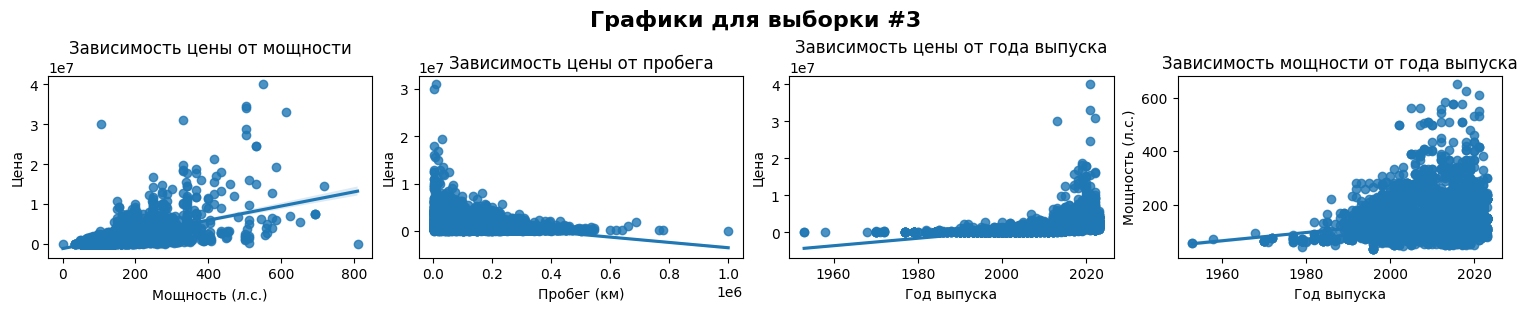

CPU times: user 4.22 s, sys: 11.7 ms, total: 4.23 s
Wall time: 4.21 s


In [ ]:
%%time

for idx, df_number in enumerate(dfs):
    fig, axes = plt.subplots(1, 4, figsize=(15, 3), constrained_layout=True)
    fig.suptitle(f"Графики для выборки #{idx + 1}", fontsize=16, fontweight="bold")

    # График 1: power vs price
    sns.regplot(data=dfs[idx], x="power", y="price", ax=axes[0])
    axes[0].set_xlabel("Мощность (л.с.)")
    axes[0].set_ylabel("Цена")
    axes[0].set_title("Зависимость цены от мощности")

    # График 2: mileage vs price
    sns.regplot(data=dfs[idx], x="mileage", y="price", ax=axes[1])
    axes[1].set_xlabel("Пробег (км)")
    axes[1].set_ylabel("Цена")
    axes[1].set_title("Зависимость цены от пробега")

    # График 3: year vs price
    sns.regplot(data=dfs[idx], x="year", y="price", ax=axes[2])
    axes[2].set_xlabel("Год выпуска")
    axes[2].set_ylabel("Цена")
    axes[2].set_title("Зависимость цены от года выпуска")

    # График 4: year vs power
    sns.regplot(data=dfs[idx], x="year", y="power", ax=axes[3])
    axes[3].set_xlabel("Год выпуска")
    axes[3].set_ylabel("Мощность (л.с.)")
    axes[3].set_title("Зависимость мощности от года выпуска")

plt.show()


In [11]:
# df1 = dfs[0][['price', 'year', 'mileage', 'power']]
# df1 = dfs
# for idx, df_number in enumerate(dfs):
#     g = sns.PairGrid(df_number, diag_sharey=False, hue="tile")
#     g.map_upper(sns.scatterplot)
#     g.map_lower(sns.regplot)
#     g.map_diag(sns.kdeplot, lw=2)
#     g.add_legend()
# plt.show()

In [12]:
end_time = time.perf_counter()
total_time = end_time - start_time
print(f"Общее время выполнения: {total_time:.4f} секунд")

Общее время выполнения: 12.5121 секунд
